In [18]:
import pandas as pd
import gseapy as gp
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

In [2]:
hallmark_gmt = "gsea_gene_set/h.all.v2025.1.Hs.symbols.gmt"
spectra_dir = Path("all_datasets_consensus/anal_pc5_c21_S1.filtered_consensus_outputs") 
out_dir = Path("gsea_results")
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# If True: writes one CSV per (K, GEP). Can be lots of files.
write_per_gep_files = False

# GSEA parameters
min_size = 15
max_size = 500
permutation_num = 1000
seed = 42

find files + parse K 

In [4]:
pattern = re.compile(r"\.gene_spectra_score\.k_(\d+)\.dt_0_01\.txt$")

spectra_files = []
for fp in spectra_dir.glob("*.gene_spectra_score.k_*.dt_0_01.txt"):
    m = pattern.search(fp.name)
    if m:
        K = int(m.group(1))
        spectra_files.append((K, fp))

if not spectra_files:
    raise FileNotFoundError(
        f"No files matched '*.gene_spectra_score.k_*.dt_0_01.txt' in {spectra_dir}"
    )

spectra_files.sort(key=lambda x: x[0])

all_rows = []

run gsea

In [5]:
for K, fp in spectra_files:
    print(f"Loading K={K}: {fp.name}")
    spectra = pd.read_csv(fp, sep="\t", index_col=0)  # rows=GEPs, cols=genes

    # Optional: ensure gene names are strings
    spectra.columns = spectra.columns.astype(str)

    for gep in spectra.index:
        # Create preranked list: genes sorted by score
        rnk = spectra.loc[gep].sort_values(ascending=False)

        # gseapy accepts: pd.Series with index=gene, values=score
        prerank_res = gp.prerank(
            rnk=rnk,
            gene_sets=hallmark_gmt,
            min_size=min_size,
            max_size=max_size,
            permutation_num=permutation_num,
            seed=seed,
            outdir=None,      # no auto-folder per run
            verbose=False
        )

        res = prerank_res.res2d.copy()
        res["K"] = K
        res["GEP"] = str(gep)
        res["spectra_file"] = fp.name

        # Standardize column names a bit (gseapy uses varying headers by version)
        # Common columns: 'Term','NES','NOM p-val','FDR q-val','ES','Lead_genes'
        # Keep what exists.
        keep_cols = ["K", "GEP", "spectra_file"] + [c for c in res.columns if c not in ["K", "GEP", "spectra_file"]]
        res = res[keep_cols]

        all_rows.append(res)

        if write_per_gep_files:
            out_csv = out_dir / f"K{K}_{gep}_hallmark_gsea.csv"
            res.to_csv(out_csv, index=False)

2026-01-09 14:20:38,534 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Loading K=5: anal_pc5_c21_S1.filtered.gene_spectra_score.k_5.dt_0_01.txt


2026-01-09 14:20:38,828 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:39,179 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:39,517 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:39,849 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:40,175 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Loading K=6: anal_pc5_c21_S1.filtered.gene_spectra_score.k_6.dt_0_01.txt


2026-01-09 14:20:40,563 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:40,951 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:41,248 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:41,571 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:41,886 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:20:42,214 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

...

2026-01-09 14:21:27,154 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:27,450 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:27,766 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:28,069 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:28,355 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:28,698 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

Loading K=20: anal_pc5_c21_S1.filtered.gene_spectra_score.k_20.dt_0_01.txt


2026-01-09 14:21:32,983 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:33,298 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:33,578 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:33,881 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:34,208 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:34,555 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

Loading K=21: anal_pc5_c21_S1.filtered.gene_spectra_score.k_21.dt_0_01.txt


2026-01-09 14:21:39,133 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:39,430 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:39,734 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:40,052 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:40,352 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-09 14:21:40,678 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

In [6]:
summary = pd.concat(all_rows, ignore_index=True)

# Make the most useful subset table (if columns exist)
col_map = {}
for c in summary.columns:
    cl = c.lower()
    if cl == "term":
        col_map[c] = "pathway"
    elif cl == "nes":
        col_map[c] = "NES"
    elif "fdr" in cl and "q" in cl:
        col_map[c] = "FDR_q"
    elif "nom" in cl and "p" in cl:
        col_map[c] = "NOM_p"
    elif cl == "es":
        col_map[c] = "ES"
    elif "lead" in cl:
        col_map[c] = "leading_edge"

summary = summary.rename(columns=col_map)

summary_path = out_dir / "hallmark_gsea_all_K_all_GEPs_tidy.csv"
summary.to_csv(summary_path, index=False)

print(f"\nDONE ✅\nWrote tidy summary to: {summary_path}")


DONE ✅
Wrote tidy summary to: gsea_results/hallmark_gsea_all_K_all_GEPs_tidy.csv


In [7]:
summary.shape

(9724, 13)

In [8]:
for K, sub in summary.groupby("K"):
    out_path = out_dir / f"K{K}_hallmark_gsea.csv"
    sub.to_csv(out_path, index=False)

In [9]:
# Define significance
sig = summary[
    (summary["FDR_q"] <= 0.25) &
    (summary["NES"].abs() >= 1.5)
]

# Count occurrences across all K and GEPs
pathway_counts = (
    sig.groupby("pathway")
       .size()
       .reset_index(name="count")
       .sort_values("count", ascending=False)
)

pathway_counts

,pathway,count
12,HALLMARK_E2F_TARGETS,186
17,HALLMARK_G2M_CHECKPOINT,163
1,HALLMARK_ALLOGRAFT_REJECTION,120
13,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,115
26,HALLMARK_INTERFERON_GAMMA_RESPONSE,101
14,HALLMARK_ESTROGEN_RESPONSE_EARLY,90
15,HALLMARK_ESTROGEN_RESPONSE_LATE,90
29,HALLMARK_MITOTIC_SPINDLE,86
9,HALLMARK_COAGULATION,84
25,HALLMARK_INTERFERON_ALPHA_RESPONSE,83


In [10]:
pathway_k_counts = (
    sig.groupby("pathway")["K"]
       .nunique()
       .reset_index(name="num_Ks")
       .sort_values("num_Ks", ascending=False)
)

pathway_k_counts

,pathway,num_Ks
0,HALLMARK_ADIPOGENESIS,17
27,HALLMARK_KRAS_SIGNALING_DN,17
19,HALLMARK_HEDGEHOG_SIGNALING,17
1,HALLMARK_ALLOGRAFT_REJECTION,17
23,HALLMARK_IL6_JAK_STAT3_SIGNALING,17
24,HALLMARK_INFLAMMATORY_RESPONSE,17
25,HALLMARK_INTERFERON_ALPHA_RESPONSE,17
26,HALLMARK_INTERFERON_GAMMA_RESPONSE,17
28,HALLMARK_KRAS_SIGNALING_UP,17
17,HALLMARK_G2M_CHECKPOINT,17


In [11]:
top_n = 50

top_pathways_per_gep = (
    summary
    .sort_values(['K', 'GEP', 'NES'], ascending=[True, True, False])
    .groupby(['K', 'GEP'])
    .head(top_n)
)

In [12]:
unique_pathways = top_pathways_per_gep['pathway'].unique()
print(f"Total unique pathways in top {top_n} across all GEPs: {len(unique_pathways)}")

Total unique pathways in top 50 across all GEPs: 44


In [13]:
top_pathways_per_gep = top_pathways_per_gep.copy()
top_pathways_per_gep['GEP_label'] = 'GEP' + top_pathways_per_gep['GEP'].astype(str) + '_k' + top_pathways_per_gep['K'].astype(str)

In [14]:
heatmap_data = top_pathways_per_gep.pivot_table(
    index='GEP_label',
    columns='pathway',
    values='NES',
    aggfunc='first'
)

In [15]:
def sort_key(label):
    # Extract GEP number and K from label like "GEP1_k5"
    parts = label.replace('GEP', '').split('_k')
    gep_num = int(parts[0])
    k_val = int(parts[1])
    return (k_val, gep_num)

In [16]:
heatmap_data = heatmap_data.loc[sorted(heatmap_data.index, key=sort_key)]

# Fill NaN with 0 (pathway not in top 50 for that GEP)
heatmap_data = heatmap_data.fillna(0)

print(f"Heatmap shape: {heatmap_data.shape[0]} GEPs x {heatmap_data.shape[1]} pathways")


Heatmap shape: 221 GEPs x 44 pathways


/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_77131/2899401707.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = heatmap_data.fillna(0)


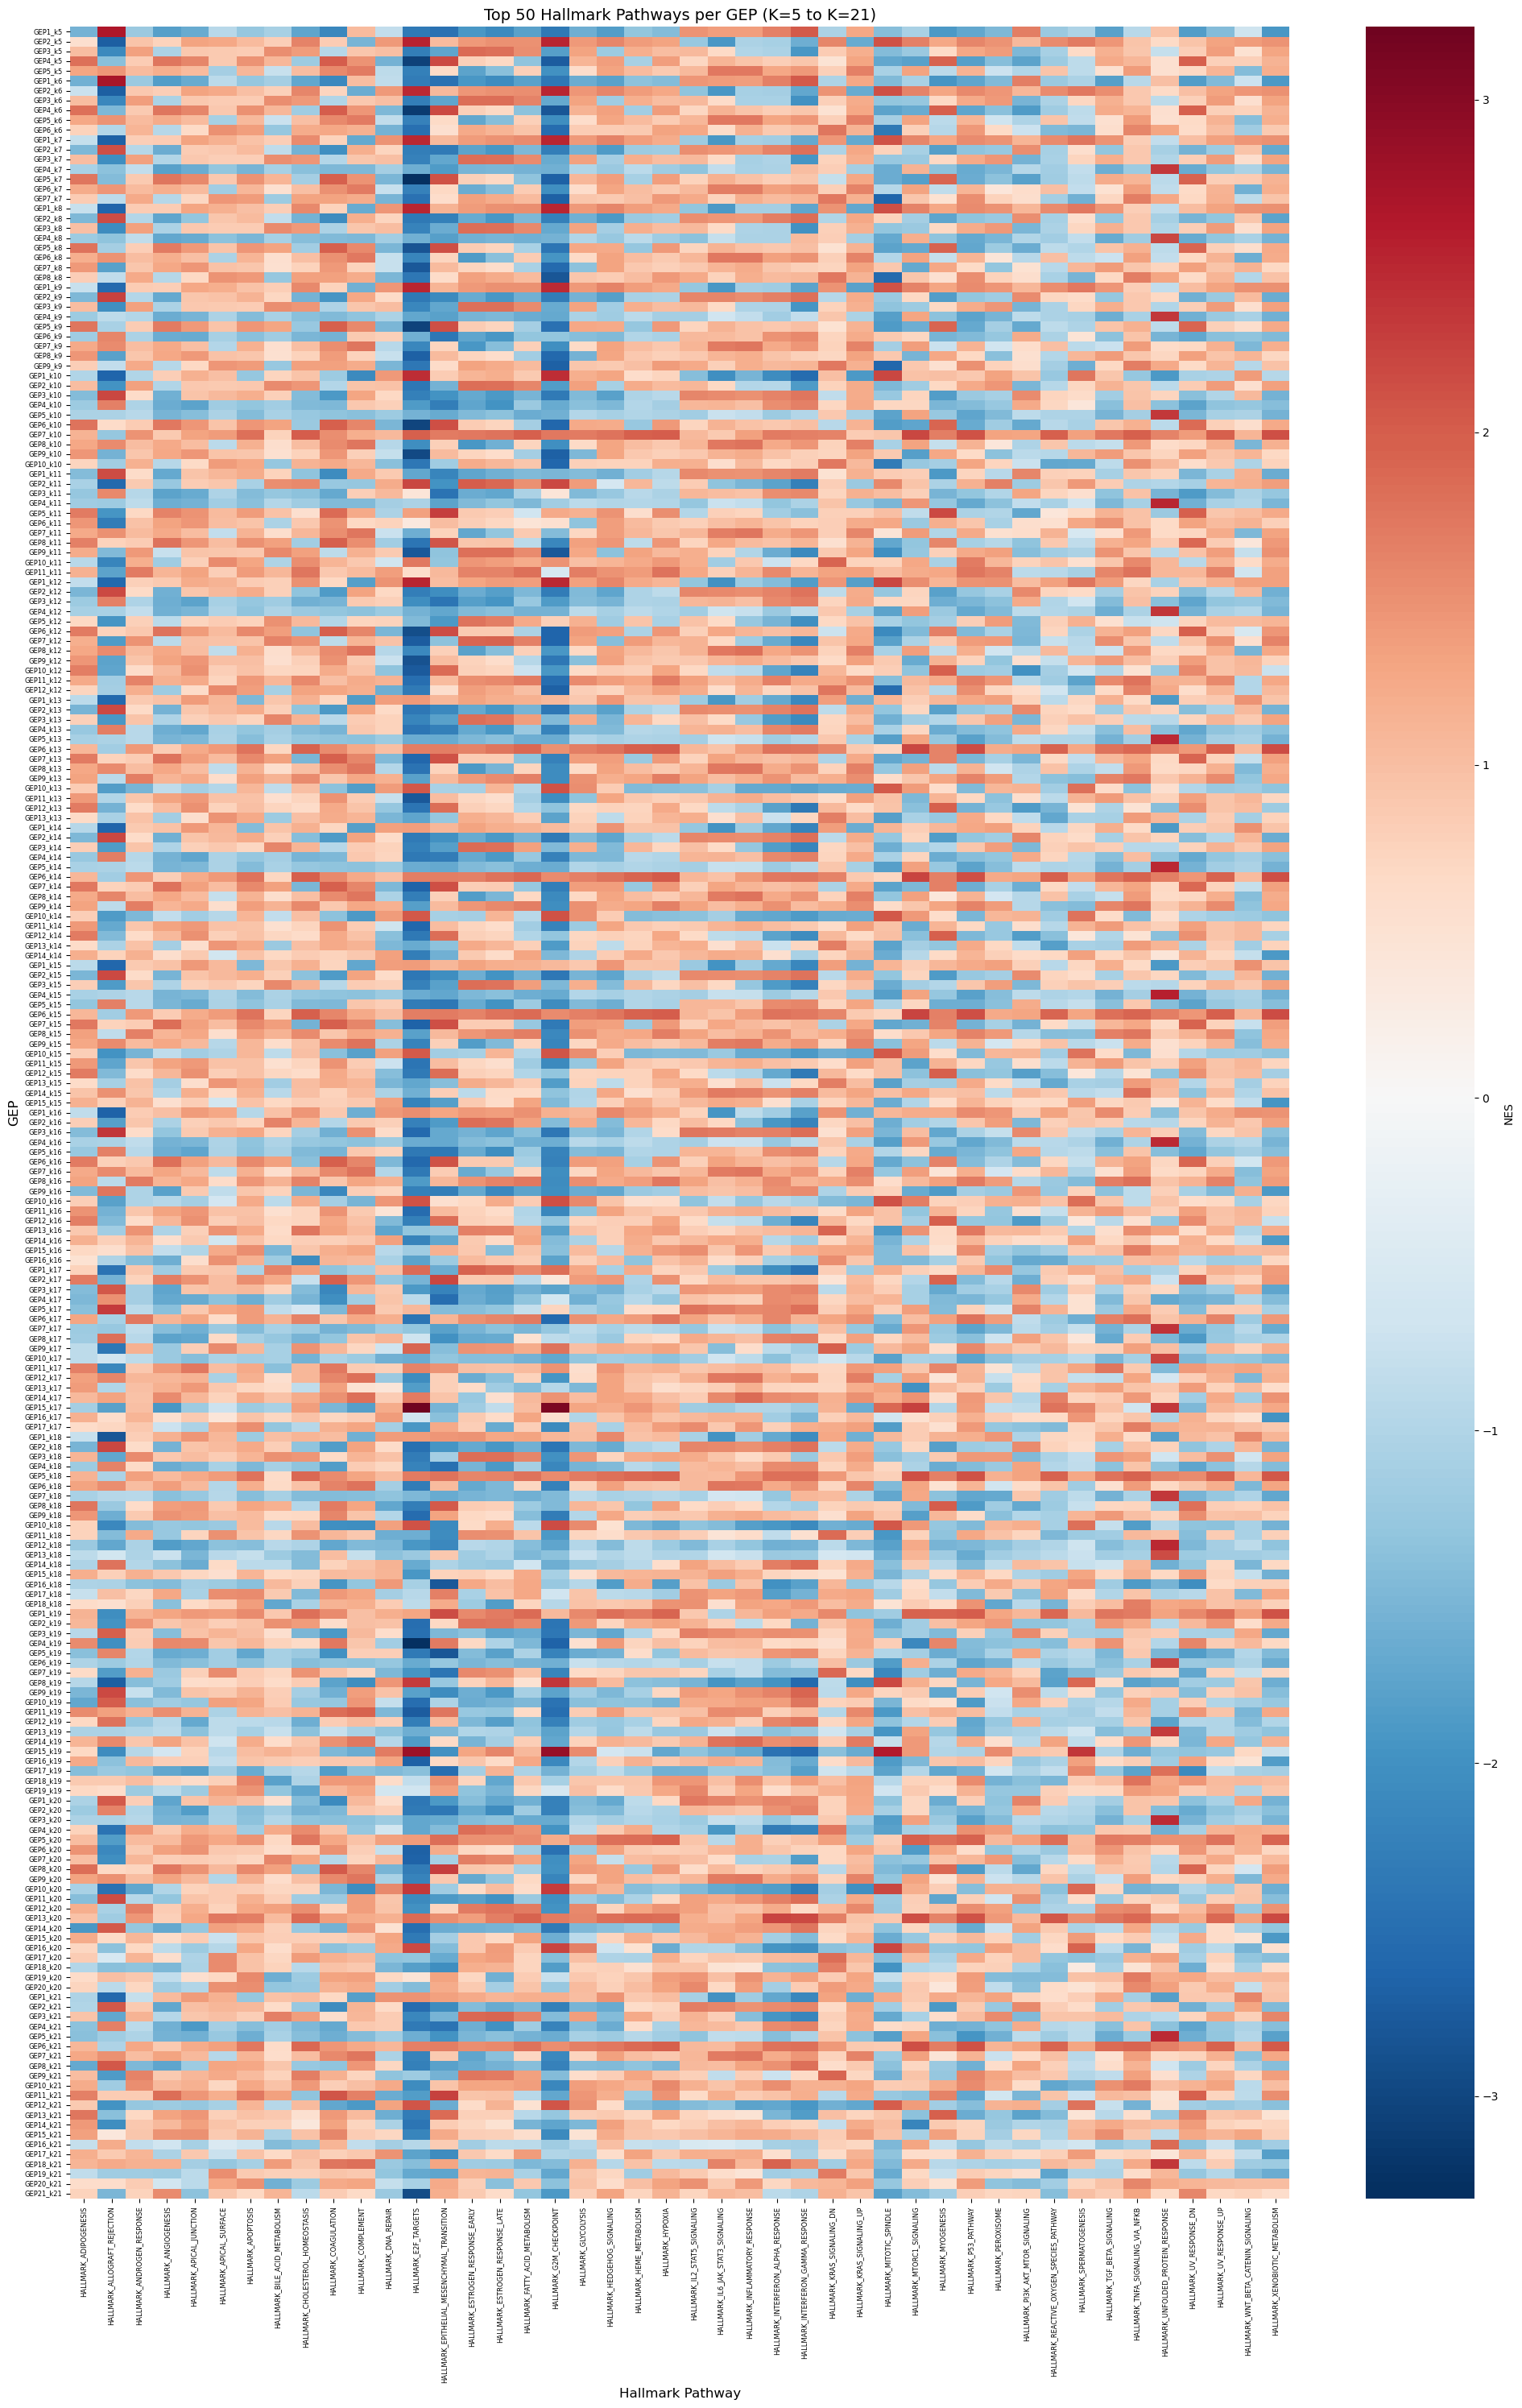

In [17]:
# Step 5: Create the heatmap
fig, ax = plt.subplots(figsize=(20, 30))

sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    xticklabels=True,
    yticklabels=True,
    ax=ax,
    cbar_kws={'label': 'NES'}
)

plt.xlabel('Hallmark Pathway', fontsize=12)
plt.ylabel('GEP', fontsize=12)
plt.title(f'Top {top_n} Hallmark Pathways per GEP (K=5 to K=21)', fontsize=14)

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

- Dark red (NES ~ +3): The pathway's genes are strongly enriched at the TOP of the GEP's ranked gene list — meaning genes in that pathway have high expression/scores in that GEP
- Dark blue (NES ~ -3): The pathway's genes are strongly enriched at the BOTTOM of the ranked list — meaning those pathway genes are suppressed/low in that GEP
- White/pale (NES ~ 0): No enrichment — the pathway genes are randomly distributed, not particularly associated with that GEP

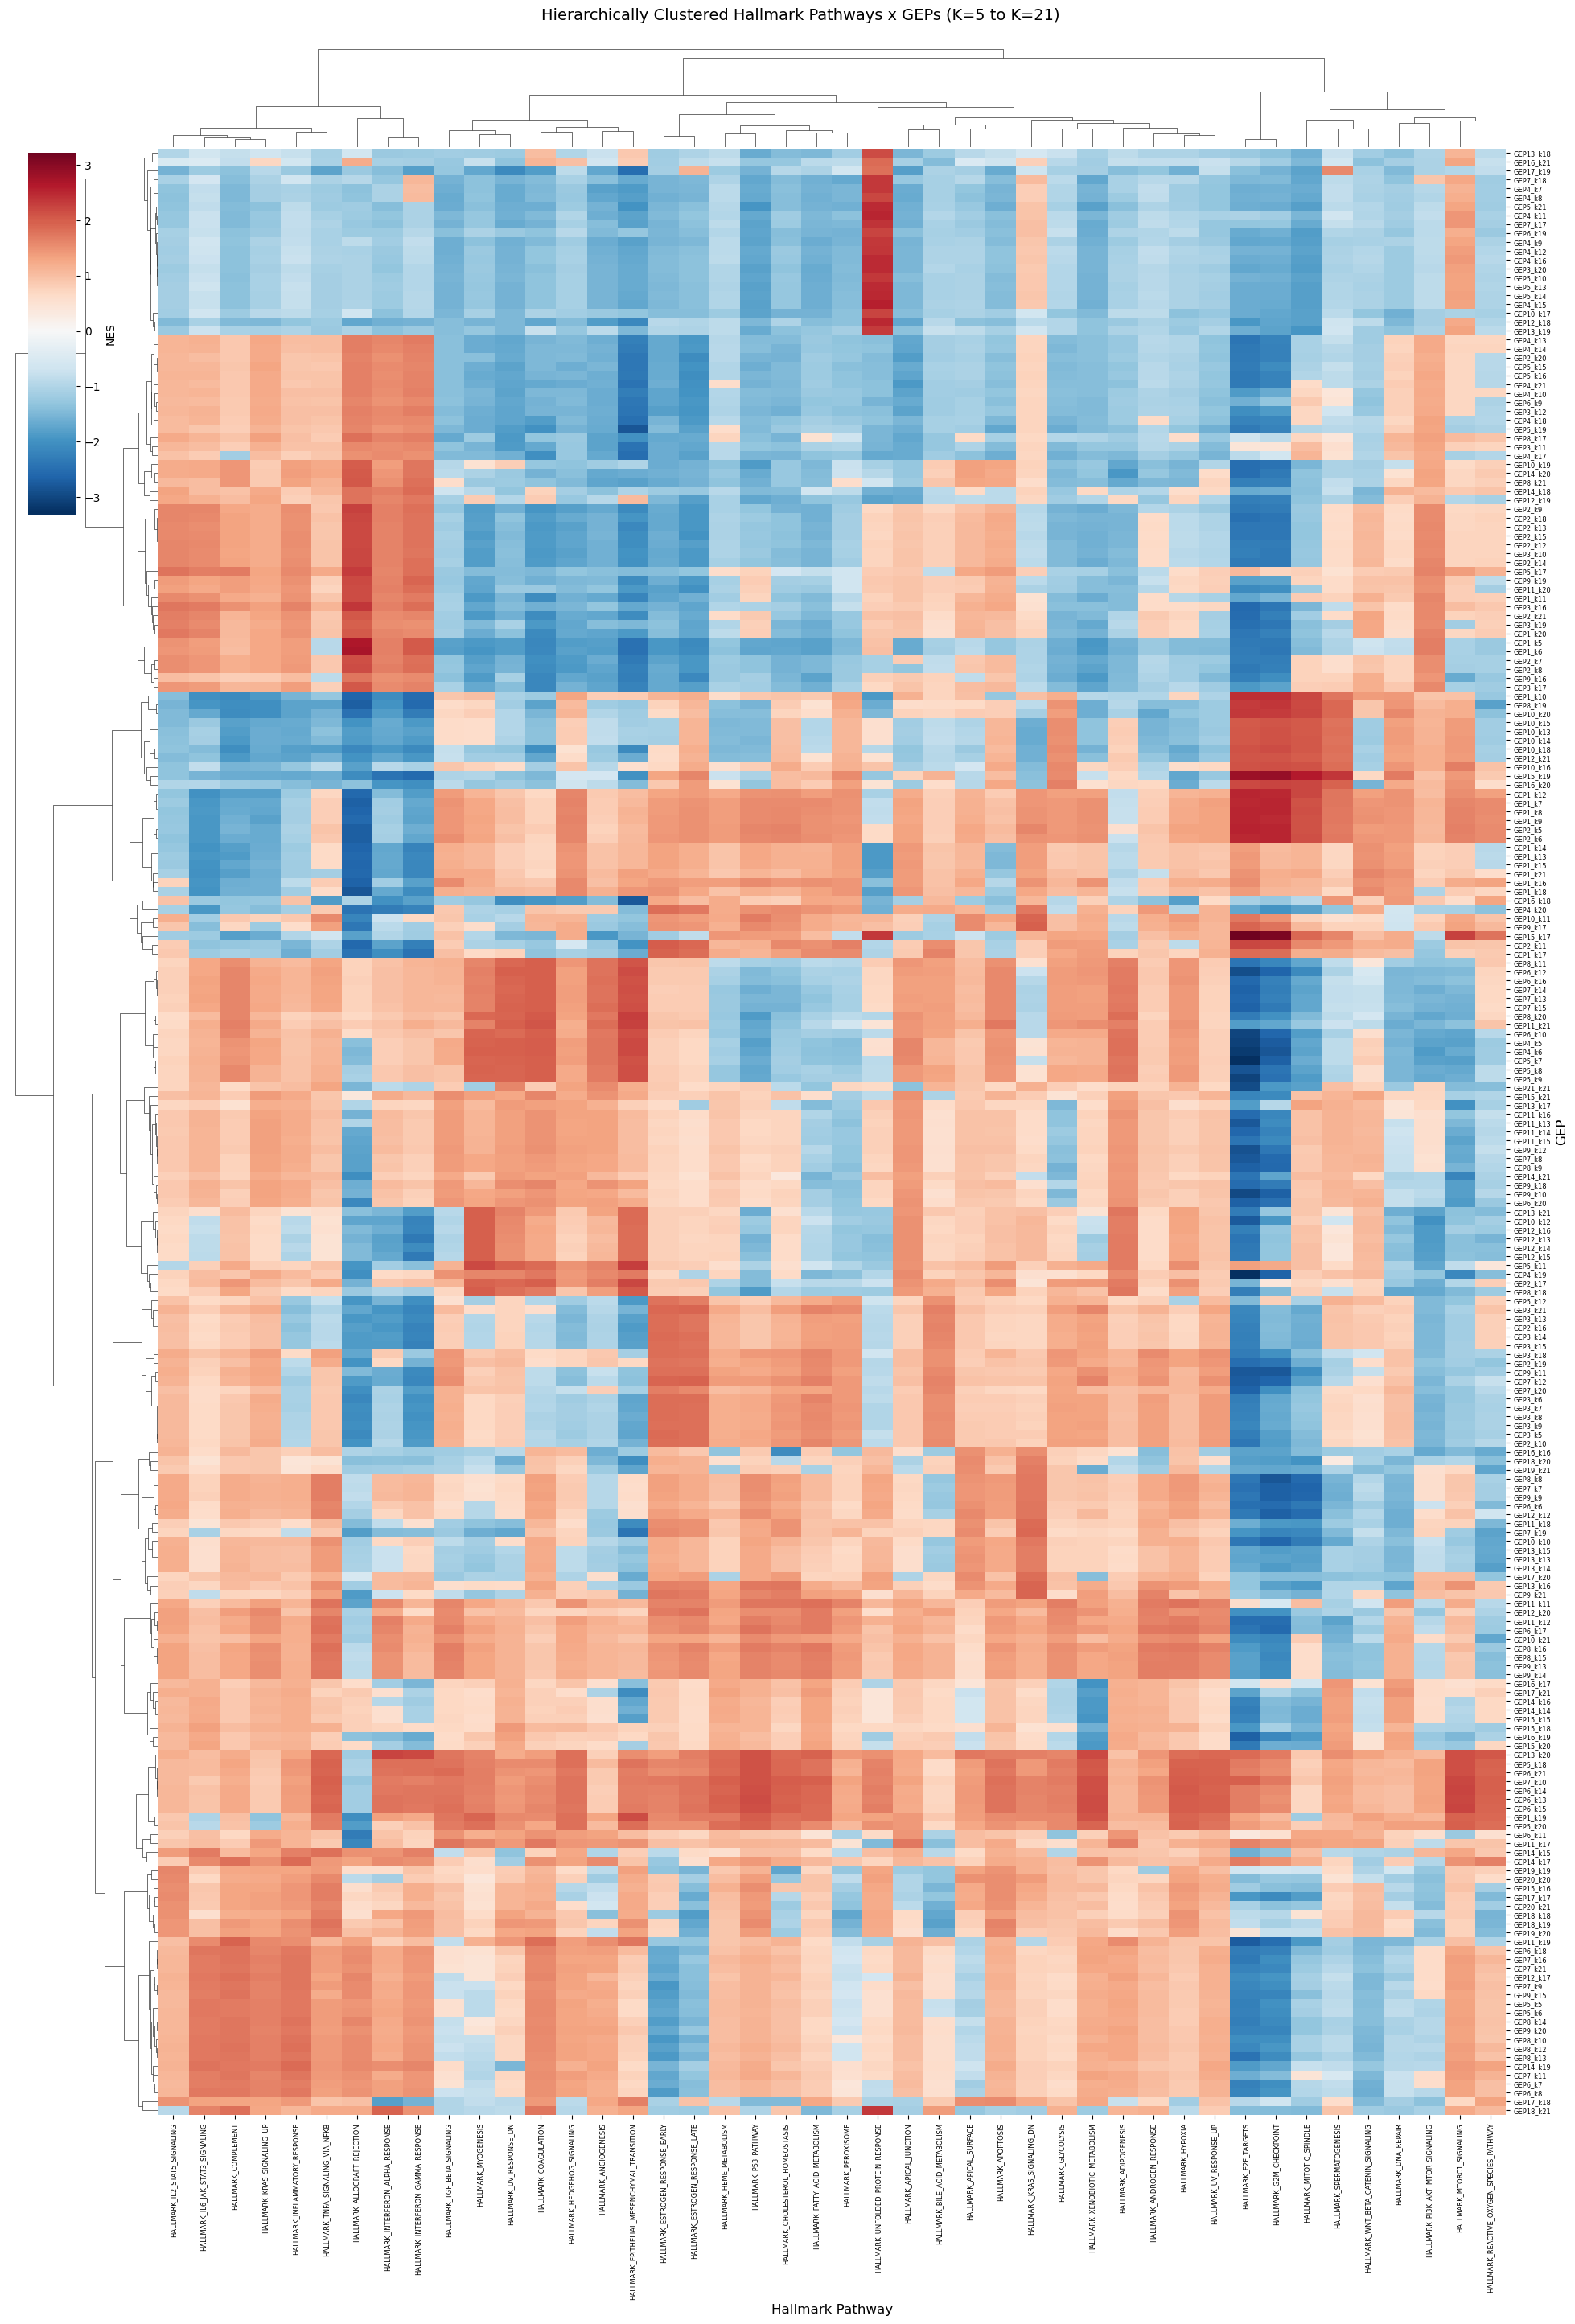

In [19]:
g = sns.clustermap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    figsize=(20, 30),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.1, 0.05),  # size of dendrograms (row, col)
    cbar_pos=(0.02, 0.8, 0.03, 0.15),  # colorbar position
    cbar_kws={'label': 'NES'},
    method='ward',  # linkage method - ward minimizes variance
    metric='euclidean',  # distance metric
    row_cluster=True,  # cluster GEPs
    col_cluster=True,  # cluster pathways
)

# Adjust labels
g.ax_heatmap.set_xlabel('Hallmark Pathway', fontsize=12)
g.ax_heatmap.set_ylabel('GEP', fontsize=12)
g.ax_heatmap.tick_params(axis='x', labelsize=6, rotation=90)
g.ax_heatmap.tick_params(axis='y', labelsize=6)

g.fig.suptitle('Hierarchically Clustered Hallmark Pathways x GEPs (K=5 to K=21)', 
               fontsize=14, y=1.01)

plt.show()